In [67]:
# Install xgboost if not already installed
!pip install xgboost

In [10]:
! pip install pandas numpy matplotlib seaborn scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

In [11]:
df= pd.read_csv('titanic.csv')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [13]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [15]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [20]:
df['Cabin'].isnull().sum()

np.int64(687)

In [21]:
df = df.drop('Cabin', axis=1)

In [22]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<Axes: xlabel='Pclass', ylabel='Age'>

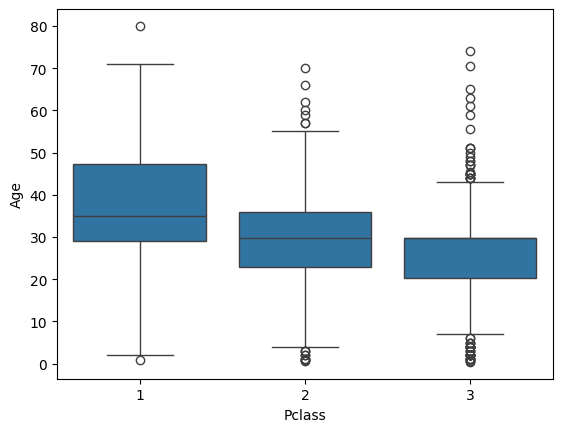

In [24]:
sns.boxplot(x='Pclass', y='Age', data=df)

## 1. Survival Count Plot
Shows the number of survivors and non-survivors.

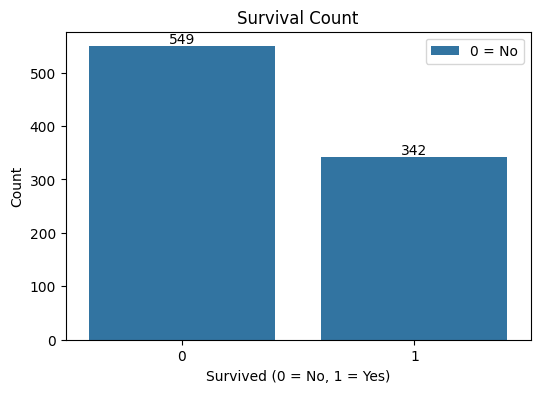

In [32]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(['0 = No', '1 = Yes'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black')
plt.show()

## 2. Survival by Gender
Shows survival rates for male and female passengers.

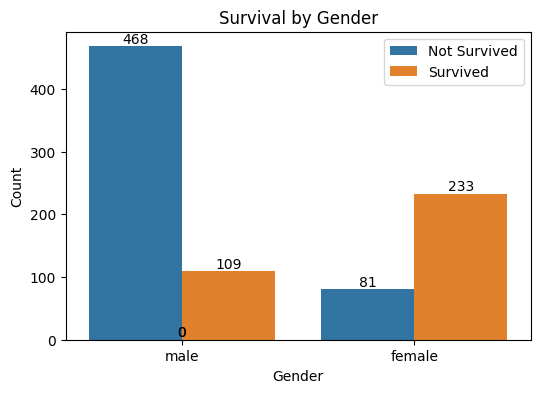

In [33]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(['Not Survived', 'Survived'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black')
plt.show()

## 3. Survival by Passenger Class
Shows survival rates for each passenger class (Pclass).

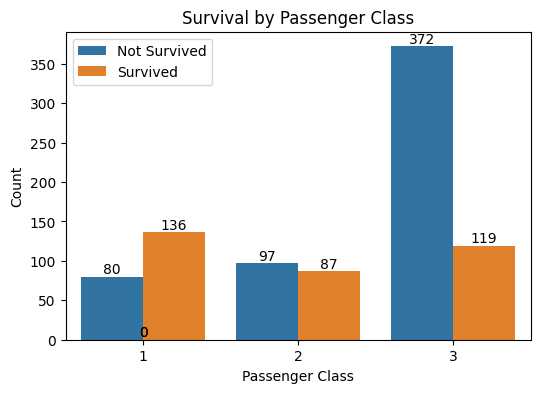

In [34]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(['Not Survived', 'Survived'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black')
plt.show()

## 4. Age Distribution
Shows the distribution of passenger ages.

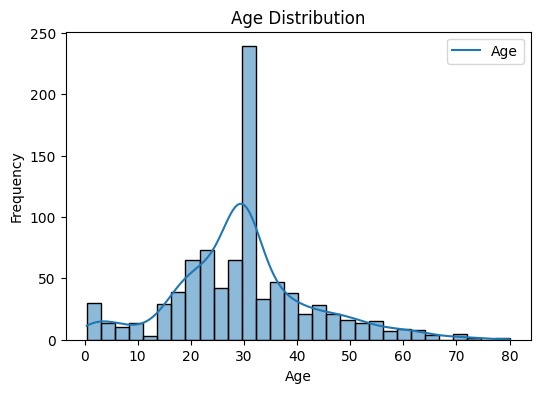

In [35]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend(['Age'])
plt.show()

## 5. Survival by Age
Shows the age distribution for survivors and non-survivors.

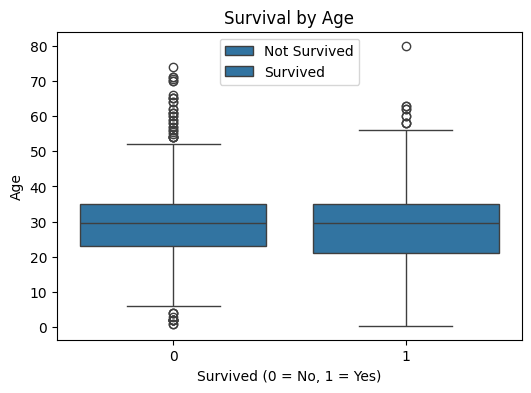

In [44]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Survival by Age')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.legend(['Not Survived', 'Survived'])
plt.show()

## 6. Fare Distribution
Shows the distribution of ticket fares.

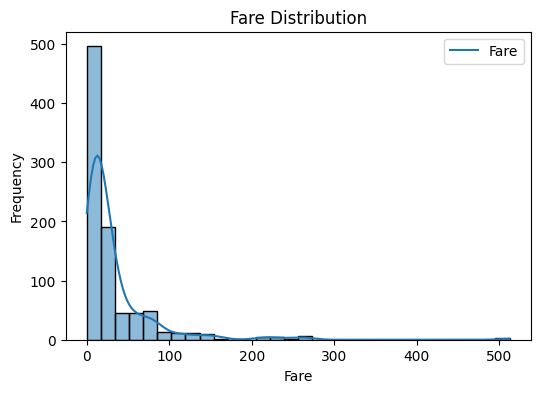

In [45]:
plt.figure(figsize=(6,4))
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.legend(['Fare'])
plt.show()

## 7. Survival by Embarked Port
Shows survival rates for each embarkation port.

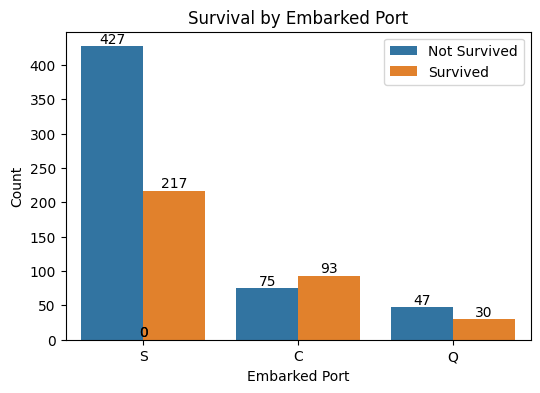

In [46]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Embarked', hue='Survived', data=df)
plt.title('Survival by Embarked Port')
plt.xlabel('Embarked Port')
plt.ylabel('Count')
plt.legend(['Not Survived', 'Survived'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black')
plt.show()

## 8. Correlation Heatmap
Shows the correlation between numerical features in the dataset.

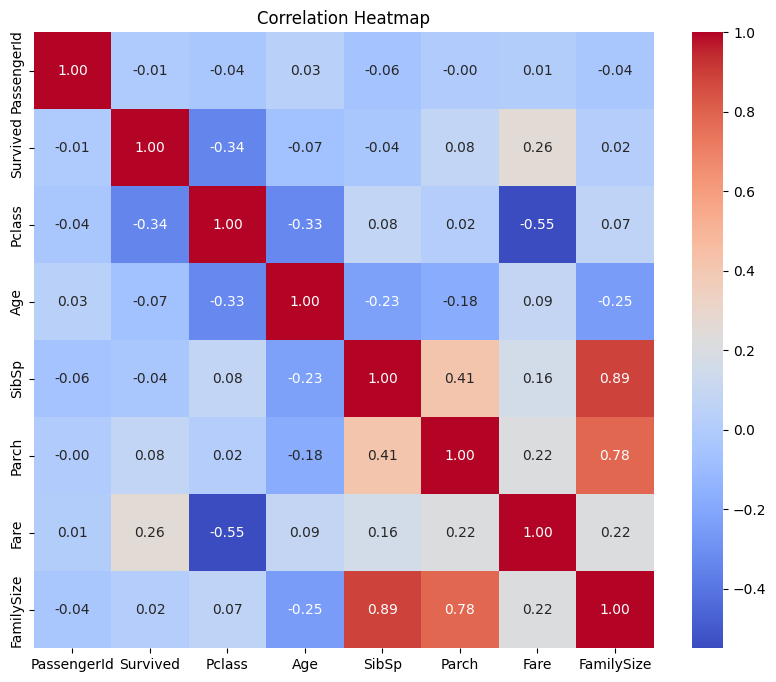

In [47]:
plt.figure(figsize=(10,8))
numerical_df = df.select_dtypes(include=['number'])  # Select only numerical columns
corr = numerical_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 9. Pairplot of Selected Features
Shows pairwise relationships between selected features, colored by survival status.

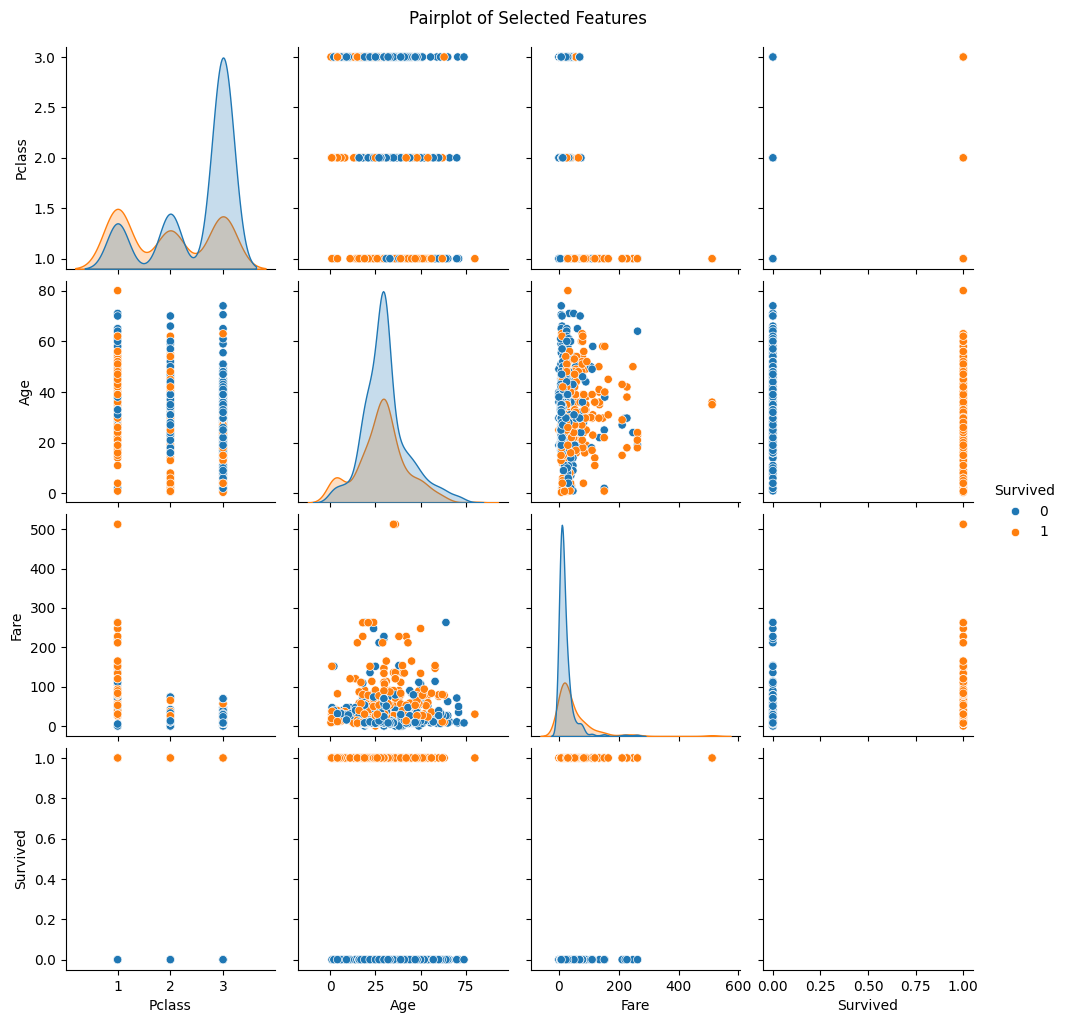

In [48]:

sns.pairplot(df, vars=['Pclass', 'Age', 'Fare', 'Survived'], hue='Survived')
plt.suptitle('Pairplot of Selected Features', y=1.02)
plt.show()

## 10. Family Size vs. Survival
Shows survival rates by family size (SibSp + Parch).

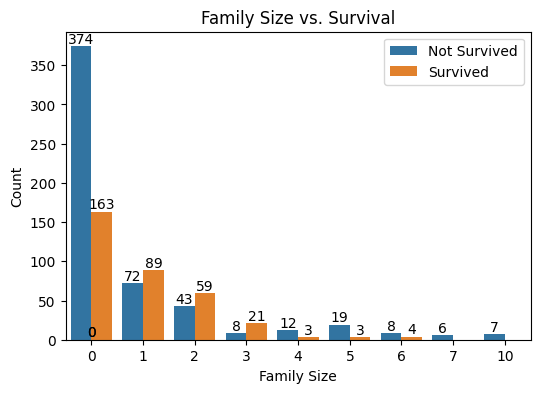

In [49]:
df['FamilySize'] = df['SibSp'] + df['Parch']
plt.figure(figsize=(6,4))
ax = sns.countplot(x='FamilySize', hue='Survived', data=df)
plt.title('Family Size vs. Survival')
plt.xlabel('Family Size')
plt.ylabel('Count')
plt.legend(['Not Survived', 'Survived'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black')
plt.show()

In [52]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


In [53]:
# Drop unimportant columns for ML modeling
df = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

In [60]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,Sex_male,Sex_female,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,1,1,0,0,0,1
1,1,1,38.0,1,0,71.2833,1,0,1,1,0,0
2,1,3,26.0,0,0,7.9250,0,0,1,0,0,1
3,1,1,35.0,1,0,53.1000,1,0,1,0,0,1
4,0,3,35.0,0,0,8.0500,0,1,0,0,0,1


In [55]:
# Encode 'Sex' column into two separate columns: 'Sex_male' and 'Sex_female'
df['Sex_male'] = (df['Sex'] == 'male').astype(int)
df['Sex_female'] = (df['Sex'] == 'female').astype(int)
df = df.drop('Sex', axis=1)

In [57]:
# Encode 'Embarked' column using one-hot encoding
embarked_dummies = pd.get_dummies(df['Embarked'], prefix='Embarked')
df = pd.concat([df, embarked_dummies], axis=1)
df = df.drop('Embarked', axis=1)

In [59]:
# Convert all boolean columns to 0/1 integers
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

## Model Training and Comparison
We will train several classification models and compare their accuracy to select the best one.

In [61]:
# Split data into features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define models to compare
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier()
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    results[name] = acc

# Show results
for name, acc in results.items():
    print(f'{name}: {acc:.4f}')

# Find the best model
best_model = max(results, key=results.get)
print(f'Best model: {best_model} with accuracy {results[best_model]:.4f}')

Logistic Regression: 0.8101
Decision Tree: 0.7877
Random Forest: 0.8212
SVM: 0.6592
KNN: 0.7207
Best model: Random Forest with accuracy 0.8212


In [65]:
# Tkinter GUI for Titanic Survival Prediction using Random Forest
import tkinter as tk
from tkinter import messagebox

def predict_survival():
    try:
        # Collect user input from entry fields
        pclass = int(entry_pclass.get())
        age = float(entry_age.get())
        sibsp = int(entry_sibsp.get())
        parch = int(entry_parch.get())
        fare = float(entry_fare.get())
        family_size = sibsp + parch
        sex_male = int(var_sex.get() == 'male')
        sex_female = int(var_sex.get() == 'female')
        embarked_c = int(var_embarked.get() == 'C')
        embarked_q = int(var_embarked.get() == 'Q')
        embarked_s = int(var_embarked.get() == 'S')
        
        # Create input array for prediction
        input_data = [[pclass, age, sibsp, parch, fare, family_size, sex_male, sex_female, embarked_c, embarked_q, embarked_s]]
        
        # Predict using trained Random Forest model
        prediction = models['Random Forest'].predict(input_data)[0]
        result = 'Survived' if prediction == 1 else 'Not Survived'
        messagebox.showinfo('Prediction Result', f'Prediction: {result}')
    except Exception as e:
        messagebox.showerror('Error', f'Invalid input: {e}')

# Create Tkinter window
root = tk.Tk()
root.title('Titanic Survival Prediction')

# Input fields
tk.Label(root, text='Pclass (1, 2, 3):').grid(row=0, column=0)
entry_pclass = tk.Entry(root)
entry_pclass.grid(row=0, column=1)

tk.Label(root, text='Age:').grid(row=1, column=0)
entry_age = tk.Entry(root)
entry_age.grid(row=1, column=1)

tk.Label(root, text='SibSp:').grid(row=2, column=0)
entry_sibsp = tk.Entry(root)
entry_sibsp.grid(row=2, column=1)

tk.Label(root, text='Parch:').grid(row=3, column=0)
entry_parch = tk.Entry(root)
entry_parch.grid(row=3, column=1)

tk.Label(root, text='Fare:').grid(row=4, column=0)
entry_fare = tk.Entry(root)
entry_fare.grid(row=4, column=1)

tk.Label(root, text='Sex:').grid(row=5, column=0)
var_sex = tk.StringVar(value='male')
tk.OptionMenu(root, var_sex, 'male', 'female').grid(row=5, column=1)

tk.Label(root, text='Embarked:').grid(row=6, column=0)
var_embarked = tk.StringVar(value='S')
tk.OptionMenu(root, var_embarked, 'C', 'Q', 'S').grid(row=6, column=1)

# Predict button
tk.Button(root, text='Predict Survival', command=predict_survival).grid(row=7, column=0, columnspan=2)

root.mainloop()

d:\Desktop\desktop\Sem3\data science\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
d:\Desktop\desktop\Sem3\data science\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
d:\Desktop\desktop\Sem3\data science\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
d:\Desktop\desktop\Sem3\data science\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
d:\Desktop\desktop\Sem3\data science\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feat

In [ ]:
# Artificial Neural Network (ANN) for Titanic Survival Prediction
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

# Scale features for ANN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build ANN model
ann_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train ANN model
history = ann_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Evaluate ANN model
ann_acc = ann_model.evaluate(X_test_scaled, y_test, verbose=0)[1]
print(f'ANN Test Accuracy: {ann_acc:.4f}')

In [70]:
# Boosting Models for Titanic Survival Prediction
%pip install xgboost
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
import xgboost as xgb

# Gradient Boosting
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)
gb_acc = gb_model.score(X_test, y_test)
print(f'Gradient Boosting Test Accuracy: {gb_acc:.4f}')

# AdaBoost
ada_model = AdaBoostClassifier()
ada_model.fit(X_train, y_train)
ada_acc = ada_model.score(X_test, y_test)
print(f'AdaBoost Test Accuracy: {ada_acc:.4f}')

# XGBoost
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_acc = xgb_model.score(X_test, y_test)
print(f'XGBoost Test Accuracy: {xgb_acc:.4f}')

# Compare boosting model accuracies
boosting_results = {
    'Gradient Boosting': gb_acc,
    'AdaBoost': ada_acc,
    'XGBoost': xgb_acc
}
for name, acc in boosting_results.items():
    print(f'{name}: {acc:.4f}')
best_boosting = max(boosting_results, key=boosting_results.get)
print(f'Best boosting model: {best_boosting} with accuracy {boosting_results[best_boosting]:.4f}')

   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
    --------------------------------------- 0.8/56.8 MB 2.1 MB/s eta 0:00:27
   - -------------------------------------- 1.8/56.8 MB 3.4 MB/s eta 0:00:17
   -- ------------------------------------- 3.4/56.8 MB 4.5 MB/s eta 0:00:12
   --- ------------------------------------ 4.7/56.8 MB 5.0 MB/s eta 0:00:11
   ---- ----------------------------------- 6.0/56.8 MB 5.4 MB/s eta 0:00:10
   ----- ---------------------------------- 7.6/56.8 MB 5.6 MB/s eta 0:00:09
   ------ --------------------------------- 9.2/56.8 MB 5.8 MB/s eta 0:00:09
   ------- -------------------------------- 10.2/56.8 MB 5.8 MB/s eta 0:00:08
   ------- -------------------------------- 11.3/56.8 MB 5.7 MB/s eta 0:00:08
   -------- ------------------------------- 12.3/56.8 MB 5.7 MB/s eta 0:00:08
   --------- ------------------------------ 14.2/56.8 MB 5.9 MB/s eta 0:00:08
   ------


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Gradient Boosting Test Accuracy: 0.8045
AdaBoost Test Accuracy: 0.8045
XGBoost Test Accuracy: 0.7933
Gradient Boosting: 0.8045
AdaBoost: 0.8045
XGBoost: 0.7933
Best boosting model: Gradient Boosting with accuracy 0.8045


d:\Desktop\desktop\Sem3\data science\env\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:48:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
